'''TASK 1 · Predicting House Prices with Linear Regression
Objective: Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age. Develop end-to-end skills from data cleaning through to model interpretation.'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

'''1.Load dataset and perform EDA: null check, descriptive statistics, distribution of the target variable'''

In [3]:
df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L2-PredHousePrice.csv")
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

                Missing Count  Percentage
Pool QC                  2917   99.556314
Misc Feature             2824   96.382253
Alley                    2732   93.242321
Fence                    2358   80.477816
Mas Vnr Type             1775   60.580205
Fireplace Qu             1422   48.532423
Lot Frontage              490   16.723549
Garage Qual               159    5.426621
Garage Cond               159    5.426621
Garage Yr Blt             159    5.426621
Garage Finish             159    5.426621
Garage Type               157    5.358362
Bsmt Exposure              83    2.832765
BsmtFin Type 2             81    2.764505
Bsmt Cond                  80    2.730375
Bsmt Qual                  80    2.730375
BsmtFin Type 1             80    2.730375
Mas Vnr Area               23    0.784983
Bsmt Full Bath              2    0.068259
Bsmt Half Bath              2    0.068259
BsmtFin SF 1                1    0.034130
BsmtFin SF 2                1    0.034130
Electrical                  1    0

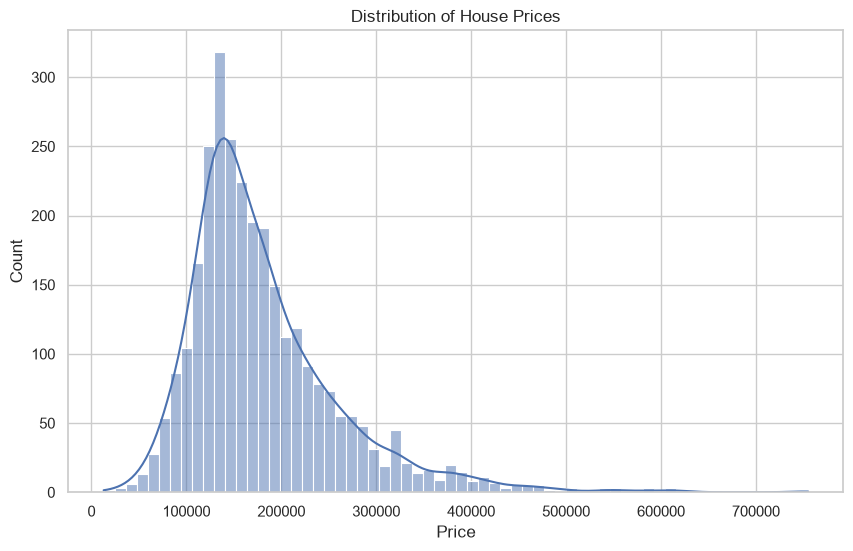

In [4]:
missing=df.isnull().sum()
missing_pct=(missing/len(df))*100
missing_df=pd.DataFrame({'Missing Count': missing,'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count']>0].sort_values(by='Missing Count',ascending=False))
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'],kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.show()

Area: GrLivArea(grade living area) and TotalBsmtSF(Total basement square feet) are typically the strongest predictors.
Quality: OverallQual(Overall quality) is highly correlated with price.
Rooms: TotRmsAbvGrd(Total rooms above grade) and BedroomAbvGr. 
Age: YearBuilt and GarageYrBlt indicate property age.
Location: Neighborhood captures location value differences

In [5]:
print(df['SalePrice'].describe())

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


'''2.Feature selection discussion: identify which features are likely predictors; explain reasoning in a markdown cell'''

In [6]:
features=['Gr Liv Area','Total Bsmt SF','Overall Qual','Year Built','Garage Yr Blt','Neighborhood','House Style','Garage Cars','TotRms AbvGrd']
target='SalePrice'
X=df[features]
y=df[target]
categorical_cols= X.select_dtypes(include=['object','string']).columns
numerical_cols= X.select_dtypes(include=['int64','float64']).columns
print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

Categorical columns: ['Neighborhood', 'House Style']
Numerical columns: ['Gr Liv Area', 'Total Bsmt SF', 'Overall Qual', 'Year Built', 'Garage Yr Blt', 'Garage Cars', 'TotRms AbvGrd']


'''3.Handle missing values and encode categorical features'''

In [7]:
numerical_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())
])
categorical_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor= ColumnTransformer(transformers=[
        ('num', numerical_transformer, numerical_cols),('cat', categorical_transformer, categorical_cols)
    ])

'''4.Correlation heatmap: identify features most correlated with house price'''

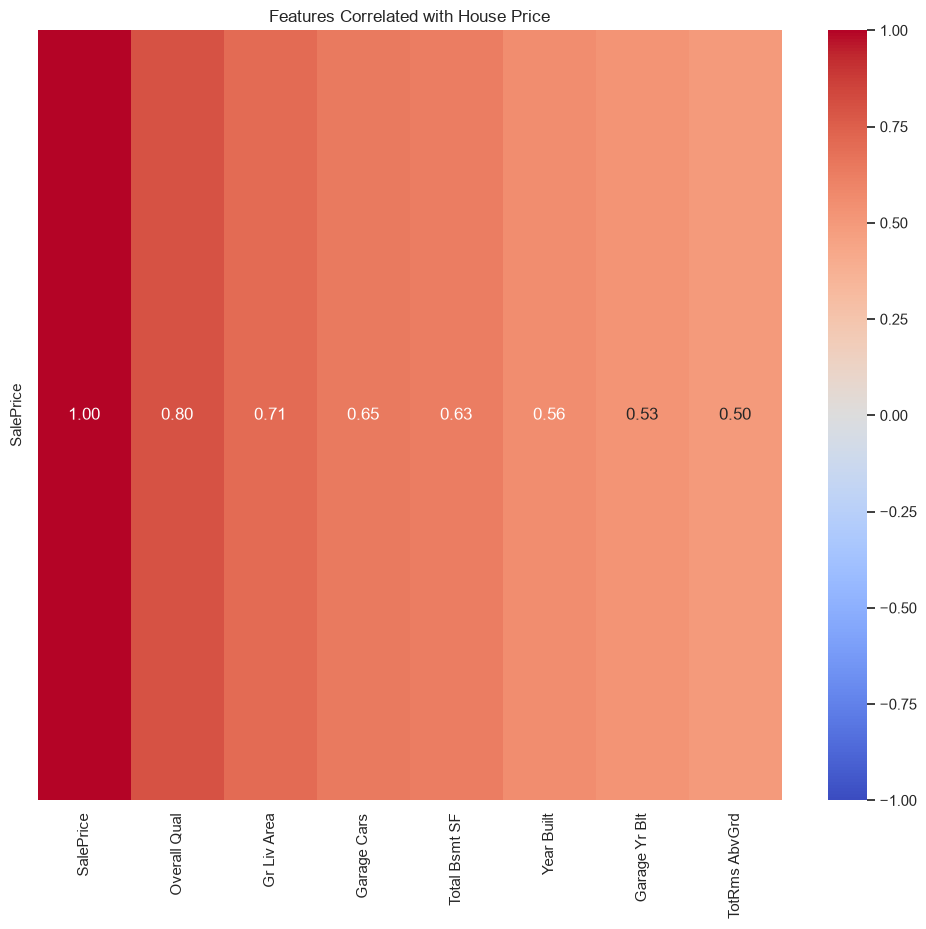

In [8]:
n_df= df[features+[target]].select_dtypes(include=[np.number]) 
plt.figure(figsize=(12,10))
corr_matrix= n_df.corr()
corr_with_target= corr_matrix[[target]].sort_values(by=target,ascending=False)
sns.heatmap(corr_with_target.T,annot=True,cmap='coolwarm',fmt=".2f",vmin=-1,vmax=1)
plt.title('Features Correlated with House Price')
plt.show()

'''5.Train/test split (80/20) & Train a Linear Regression model using scikit-learn'''

In [9]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Training set size: {X_train.shape[0]},Test set size: {X_test.shape[0]}")

Training set size: 2344,Test set size: 586


In [10]:
model_pipeline= Pipeline(steps=[
    ('preprocessor',preprocessor),('regressor',LinearRegression())
])
model_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Gr Liv Area','Total Bsmt SF','Overall Qual',...,'House Style', 'Garage Cars','TotRms AbvGrd']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throu

'''6.Evaluate model using: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score'''

In [11]:
y_pred= model_pipeline.predict(X_test)
mse= mean_squared_error(y_test,y_pred)
rmse= np.sqrt(mse)
r2= r2_score(y_test,y_pred)
print(f"\nModel Evaluation")
print(f"Mean Squared Error: ${mse:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")


Model Evaluation
Mean Squared Error: $1,309,738,165.94
Root Mean Squared Error: $36,190.30
R² Score: 0.8366


'''7.Scatter plot:actual prices vs predicted prices'''

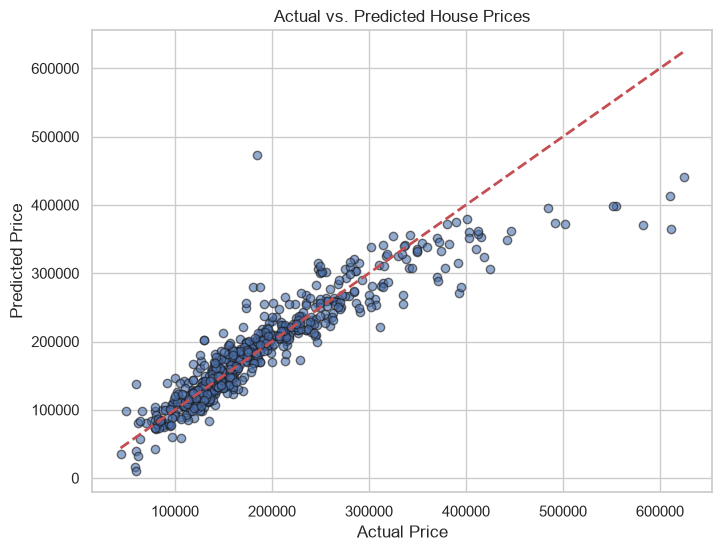

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.6,edgecolors='k')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted House Prices')
plt.grid(True)
plt.show()

'''8.Residual plot'''

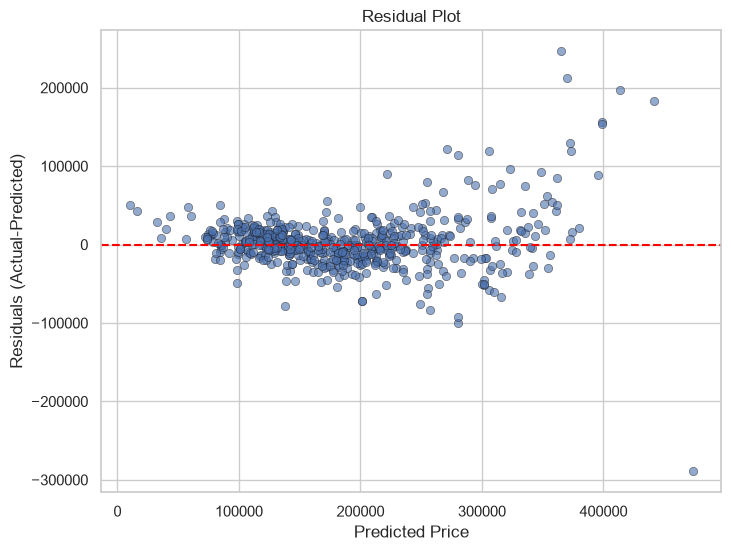

In [13]:
residuals= y_test-y_pred
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred,y=residuals,alpha=0.6,edgecolors='k')
plt.axhline(0,color='red',linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual-Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

'''9.Coefficient analysis'''


Top 10 Positive Impacts
                 Feature   Coefficient
17  Neighborhood_GrnHill  88454.298888
32  Neighborhood_StoneBr  55214.967774
26  Neighborhood_NridgHt  42933.545123
25  Neighborhood_NoRidge  42567.610408
0            Gr Liv Area  31698.664373
2           Overall Qual  23378.412119
13  Neighborhood_Crawfor  17558.574267
41    House Style_SFoyer  15726.780659
11  Neighborhood_ClearCr  13194.865698
34  Neighborhood_Veenker  12022.154962

Top 10 Negative Impacts
                 Feature   Coefficient
28    Neighborhood_SWISU -14895.545560
24   Neighborhood_NWAmes -14918.809305
27  Neighborhood_OldTown -15118.381966
20  Neighborhood_MeadowV -15417.586826
16   Neighborhood_Greens -16474.188087
7   Neighborhood_Blmngtn -22881.080102
23  Neighborhood_NPkVill -27629.866850
9    Neighborhood_BrDale -27654.317107
19  Neighborhood_Landmrk -30721.622497
8   Neighborhood_Blueste -31823.230763


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_18040\1485813477.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient',y='Feature',data=coef_df.head(15),palette='viridis')


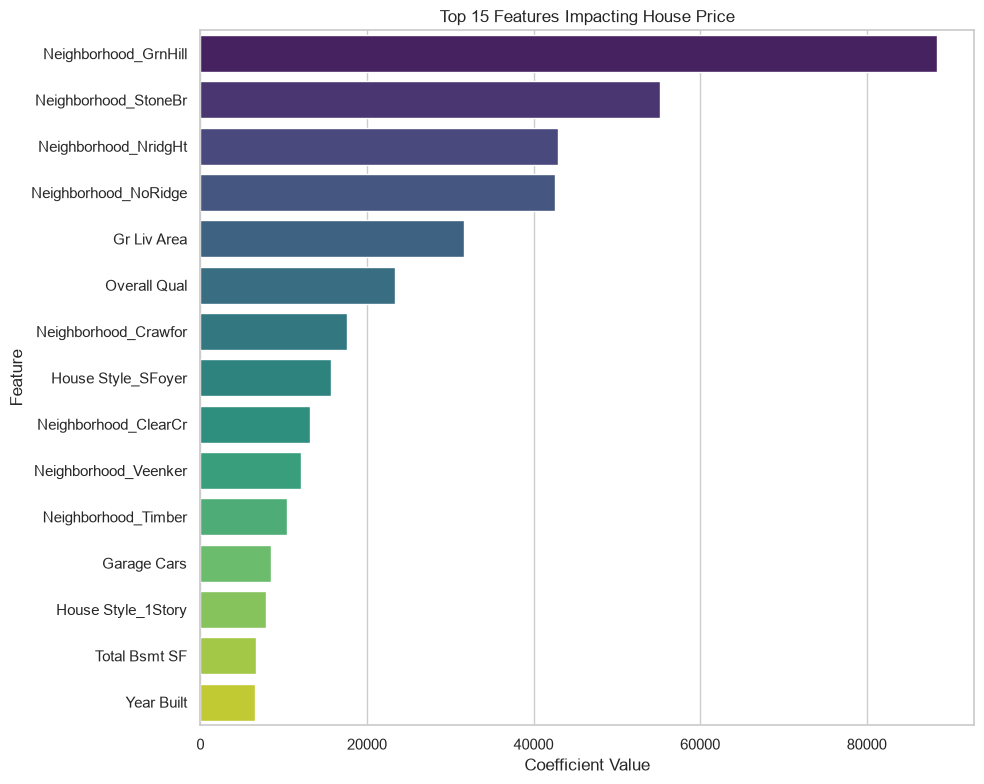

In [14]:
linear_model=model_pipeline.named_steps['regressor']
preprocessor_fit=model_pipeline.named_steps['preprocessor']
ohe = preprocessor_fit.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = np.concatenate([numerical_cols, cat_feature_names])

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': linear_model.coef_
}).sort_values(by='Coefficient', ascending=False)
print("\nTop 10 Positive Impacts")
print(coef_df.head(10))
print("\nTop 10 Negative Impacts")
print(coef_df.tail(10))
plt.figure(figsize=(10,8))
sns.barplot(x='Coefficient',y='Feature',data=coef_df.head(15),palette='viridis')
plt.title('Top 15 Features Impacting House Price')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

'''10.Compare Linear Regression against a Ridge or Lasso regularised model'''


Model Comparison
               Model          RMSE        R2
0  Linear Regression  36190.304861  0.836641
1   Ridge Regression  36193.279183  0.836614
2   Lasso Regression  36190.800149  0.836637


C:\Users\Ayush Singh\AppData\Local\Temp\ipykernel_18040\2485786902.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=results_df, palette='coolwarm')


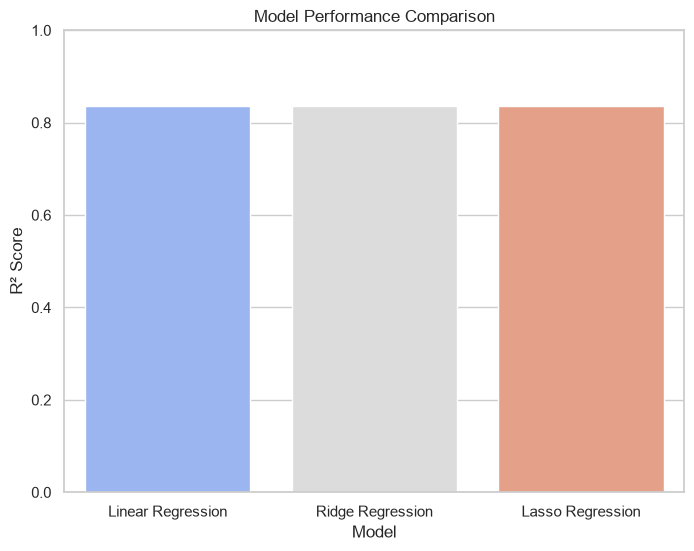

In [15]:
models= {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0, max_iter=10000) # Increase iter for convergence
}
results=[]
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred_temp = pipeline.predict(X_test)
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_temp)),
        'R2': r2_score(y_test, y_pred_temp)
    })
results_df = pd.DataFrame(results)
print("\nModel Comparison")
print(results_df)
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='R2', data=results_df, palette='coolwarm')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison')
plt.ylim(0, 1)
plt.show()